# Dane: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [ ]:
#!/bin/bash
!kaggle datasets download gagandeep16/car-sales

Dataset URL: https://www.kaggle.com/datasets/gagandeep16/car-sales
License(s): CC0-1.0
  0% 0.00/6.82k [00:00<?, ?B/s]
100% 6.82k/6.82k [00:00<00:00, 390kB/s]


In [ ]:
!unzip car-sales.zip

Archive:  car-sales.zip
  inflating: Car_sales.csv           


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Car_sales.csv')
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [ ]:
df_number = df.select_dtypes(include='number')  # wybieram dane numeryczne

In [ ]:
df_corr = df_number.corr()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

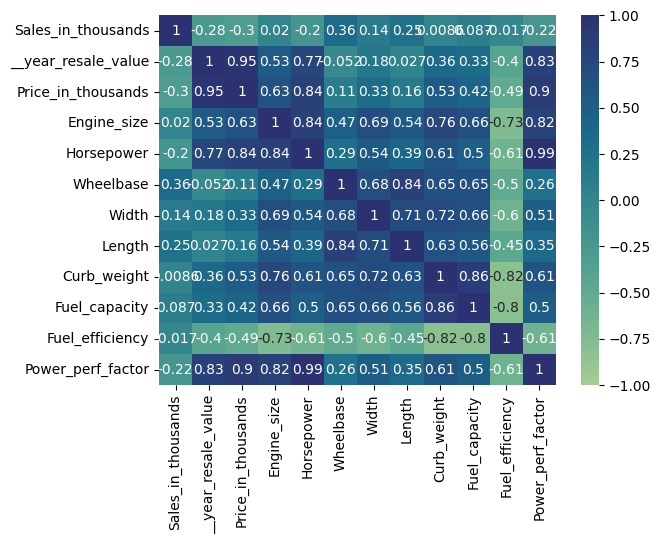

In [ ]:
sns.heatmap(df_corr, annot=True, vmin=-1, vmax=1, cmap="crest")
plt.show()

## Zadanie: Policzyć średnią cenę auta dla każego producenta, wynik ma być data frame

In [ ]:
df_groupby = df.groupby(by='Manufacturer')


In [ ]:
df_price_mean = df_groupby.mean('Price_in_thousands')[['Price_in_thousands']]  # df_groupby.mean('Price_in_thousands')['Sales_in_thousands'] to będzie data series

In [ ]:
df_price_mean.sort_values(by='Price_in_thousands', ascending=False, inplace=True)
df_price_mean

,Price_in_thousands
Manufacturer,
Porsche,62.473333
Mercedes-B,52.916667
Lexus,44.055000
Jaguar,42.800000
Lincoln,41.690000
Cadillac,40.254000
Audi,39.980000
BMW,33.096667
Volvo,30.933333


## Wykres bar plot

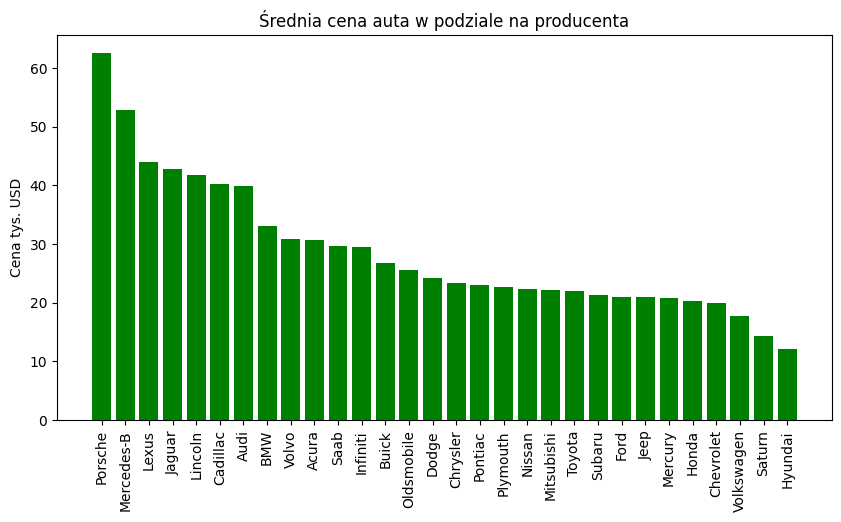

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(df_price_mean.index, df_price_mean['Price_in_thousands'], color='green')
plt.xticks(rotation=90)
plt.title("Średnia cena auta w podziale na producenta")
plt.ylabel("Cena tys. USD")
plt.show()

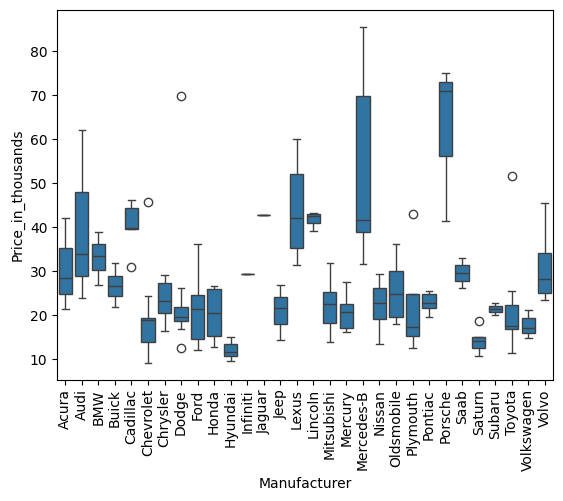

In [ ]:
sns.boxplot(x='Manufacturer', y='Price_in_thousands', data=df)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_groupby.describe()['Price_in_thousands']

,count,mean,std,min,25%,50%,75%,max
Manufacturer,,,,,,,,
Acura,3.0,30.633333,10.430884,21.500,24.95000,28.4000,35.20000,42.000
Audi,3.0,39.980000,19.709406,23.990,28.97000,33.9500,47.97500,62.000
BMW,3.0,33.096667,5.960791,26.990,30.19500,33.4000,36.15000,38.900
Buick,4.0,26.781250,4.218359,21.975,24.46875,26.5925,28.90500,31.965
Cadillac,5.0,40.254000,5.903326,31.010,39.66500,39.8950,44.47500,46.225
Chevrolet,9.0,20.022778,10.560628,9.235,13.96000,18.8900,19.39000,45.705
Chrysler,6.0,23.430833,4.918479,16.480,20.44125,23.3700,27.37875,29.185
Dodge,11.0,24.213636,15.465640,12.640,18.81000,19.5650,21.91000,69.725
Ford,11.0,21.047273,8.039550,12.050,14.67500,21.4100,24.56500,36.135


In [ ]:
df_groupby.describe()['Price_in_thousands'][['25%','50%', '75%', 'max']]

,25%,50%,75%,max
Manufacturer,,,,
Acura,24.95000,28.4000,35.20000,42.000
Audi,28.97000,33.9500,47.97500,62.000
BMW,30.19500,33.4000,36.15000,38.900
Buick,24.46875,26.5925,28.90500,31.965
Cadillac,39.66500,39.8950,44.47500,46.225
Chevrolet,13.96000,18.8900,19.39000,45.705
Chrysler,20.44125,23.3700,27.37875,29.185
Dodge,18.81000,19.5650,21.91000,69.725
Ford,14.67500,21.4100,24.56500,36.135


In [ ]:
df_max = df_groupby.describe()['Price_in_thousands'][['max']]  #  ustalam najdroższe auto dla każego producenta
df_max.reset_index(inplace=True)

In [ ]:
df_with_max = df.merge(df_max, on='Manufacturer')  # dodaję cena aut najdrożyszch do dataframe

In [ ]:
df_with_max[df_with_max['Price_in_thousands'] == df_with_max['max']]  #  wybieram model o cenie największej

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,max
3,Acura,RL,8.588,29.725,Passenger,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779,42.000
6,Audi,A8,1.380,39.000,Passenger,62.000,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,2/27/2012,134.656858,62.000
9,BMW,528i,17.527,36.125,Passenger,38.900,2.8,193.0,111.4,70.9,188.0,3.472,18.5,25.0,4/4/2011,83.998724,38.900
12,Buick,Park Avenue,27.851,20.190,Passenger,31.965,3.8,205.0,113.8,74.7,206.8,3.778,18.5,24.0,3/23/2012,85.828408,31.965
18,Cadillac,Escalade,14.785,NaN,Car,46.225,5.7,255.0,117.5,77.0,201.2,5.572,30.0,15.0,4/17/2012,109.509117,46.225
24,Chevrolet,Corvette,17.947,36.225,Passenger,45.705,5.7,345.0,104.5,73.6,179.7,3.210,19.1,22.0,5/12/2012,141.141150,45.705
34,Chrysler,300M,30.696,NaN,Passenger,29.185,3.5,253.0,113.0,74.4,197.8,3.567,17.0,23.0,2/10/2012,101.655244,29.185
39,Dodge,Viper,0.916,58.470,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,8/7/2011,188.144323,69.725
54,Ford,Expedition,125.338,23.575,Car,36.135,4.6,240.0,119.0,78.7,204.6,4.808,26.0,16.0,9/14/2012,100.024802,36.135
60,Honda,Passport,12.855,17.525,Car,26.600,3.2,205.0,106.4,70.4,178.2,3.857,21.1,19.0,10/9/2012,83.602501,26.600


In [ ]:
df.groupby("Manufacturer")['Price_in_thousands'].idxmax()

,Price_in_thousands
Manufacturer,
Acura,3
Audi,6
BMW,9
Buick,12
Cadillac,18
Chevrolet,24
Chrysler,34
Dodge,39
Ford,54


In [ ]:
df.loc[df.groupby("Manufacturer")['Price_in_thousands'].idxmax()]  # to jest dobry kod

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
3,Acura,RL,8.588,29.725,Passenger,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
6,Audi,A8,1.380,39.000,Passenger,62.000,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,2/27/2012,134.656858
9,BMW,528i,17.527,36.125,Passenger,38.900,2.8,193.0,111.4,70.9,188.0,3.472,18.5,25.0,4/4/2011,83.998724
12,Buick,Park Avenue,27.851,20.190,Passenger,31.965,3.8,205.0,113.8,74.7,206.8,3.778,18.5,24.0,3/23/2012,85.828408
18,Cadillac,Escalade,14.785,NaN,Car,46.225,5.7,255.0,117.5,77.0,201.2,5.572,30.0,15.0,4/17/2012,109.509117
24,Chevrolet,Corvette,17.947,36.225,Passenger,45.705,5.7,345.0,104.5,73.6,179.7,3.210,19.1,22.0,5/12/2012,141.141150
34,Chrysler,300M,30.696,NaN,Passenger,29.185,3.5,253.0,113.0,74.4,197.8,3.567,17.0,23.0,2/10/2012,101.655244
39,Dodge,Viper,0.916,58.470,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,8/7/2011,188.144323
54,Ford,Expedition,125.338,23.575,Car,36.135,4.6,240.0,119.0,78.7,204.6,4.808,26.0,16.0,9/14/2012,100.024802
60,Honda,Passport,12.855,17.525,Car,26.600,3.2,205.0,106.4,70.4,178.2,3.857,21.1,19.0,10/9/2012,83.602501


In [ ]:
df_max_price = df.loc[df.groupby('Manufacturer')['Price_in_thousands'].idxmax()]

df_max_price_sorted = df_max_price.sort_values('Price_in_thousands', ascending=False)

print(df_max_price_sorted[['Manufacturer', 'Model', 'Price_in_thousands']])

    Manufacturer           Model  Price_in_thousands
99    Mercedes-B           CL500              85.500
126      Porsche  Carrera Cabrio              74.970
39         Dodge           Viper              69.725
6           Audi              A8              62.000
74         Lexus           LX470              60.105
144       Toyota    Land Cruiser              51.728
18      Cadillac        Escalade              46.225
24     Chevrolet        Corvette              45.705
155        Volvo             C70              45.500
77       Lincoln        Town car              43.330
117     Plymouth         Prowler              43.000
66        Jaguar          S-Type              42.800
3          Acura              RL              42.000
9            BMW            528i              38.900
111   Oldsmobile          Aurora              36.229
54          Ford      Expedition              36.135
127         Saab           5-Sep              33.120
12         Buick     Park Avenue              